PROYECTO: PREDICCIÓN DE RIESGO DE DIABETES

1. GENERACIÓN DEL DATASET
----------------------------------------------------------------------
Dataset generado: 100 registros, 4 columnas

Primeras 5 filas:
   Edad  Peso_kg   IMC  Riesgo_Diabetes
0    56     83.2  25.5                1
1    69     78.6  26.0                1
2    46    123.8  42.8                1
3    32    106.8  34.9                1
4    60     72.8  23.3                0


Estadísticas descriptivas:
            Edad     Peso_kg        IMC  Riesgo_Diabetes
count  100.00000  100.000000  100.00000           100.00
mean    50.75000   86.091000   28.31300             0.55
std     19.60075   23.375227    8.30072             0.50
min     19.00000   45.000000   12.70000             0.00
25%     34.75000   67.475000   22.50000             0.00
50%     52.50000   83.500000   28.00000             1.00
75%     69.00000  104.100000   34.75000             1.00
max     80.00000  129.800000   48.90000             1.00


Distribución

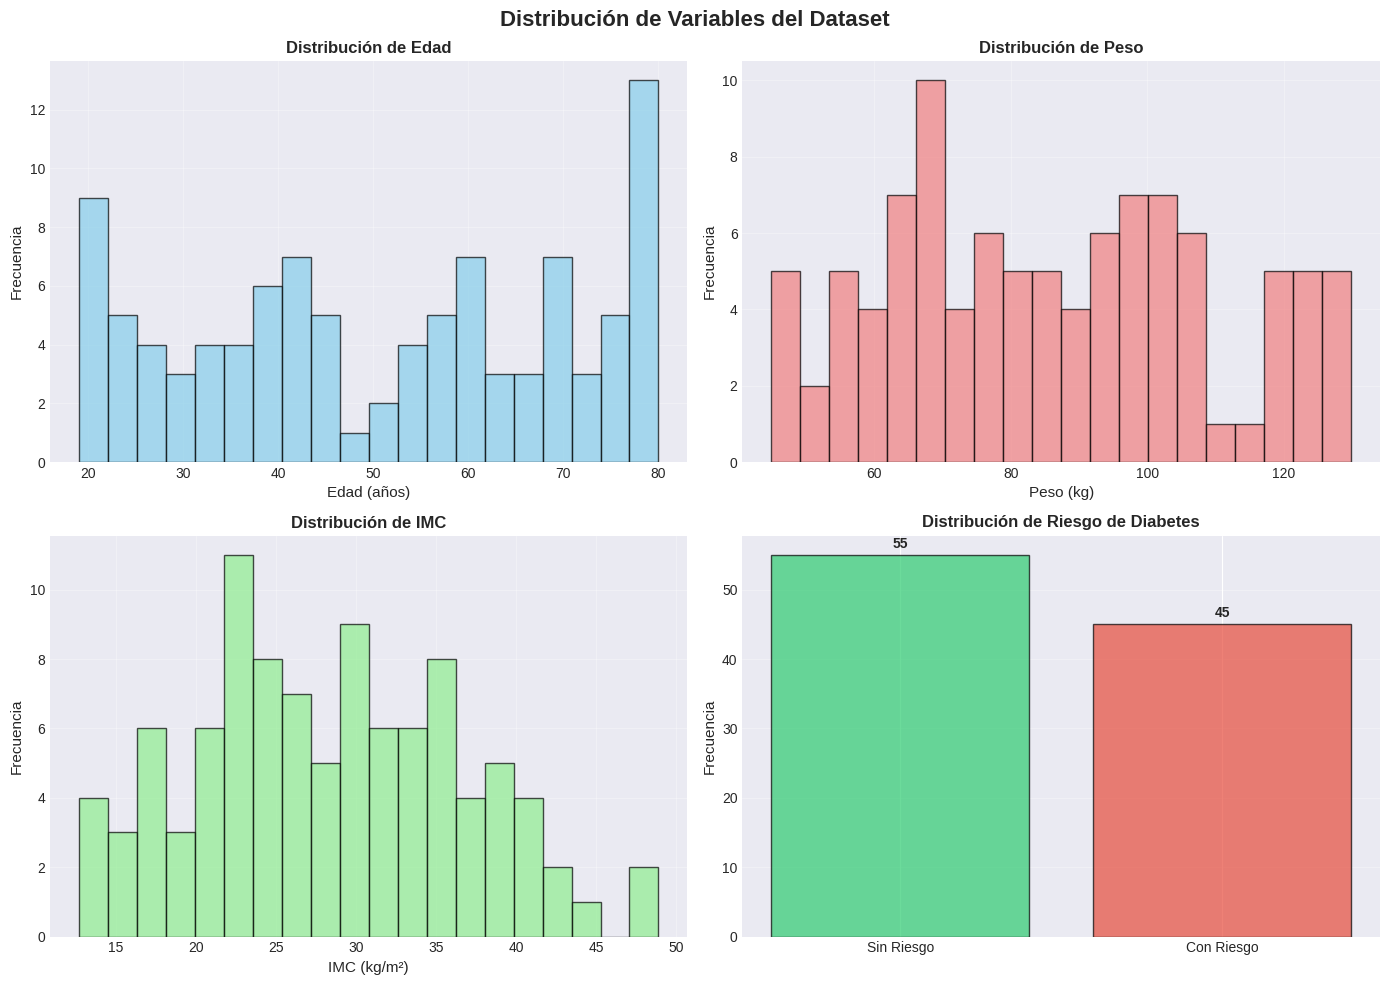

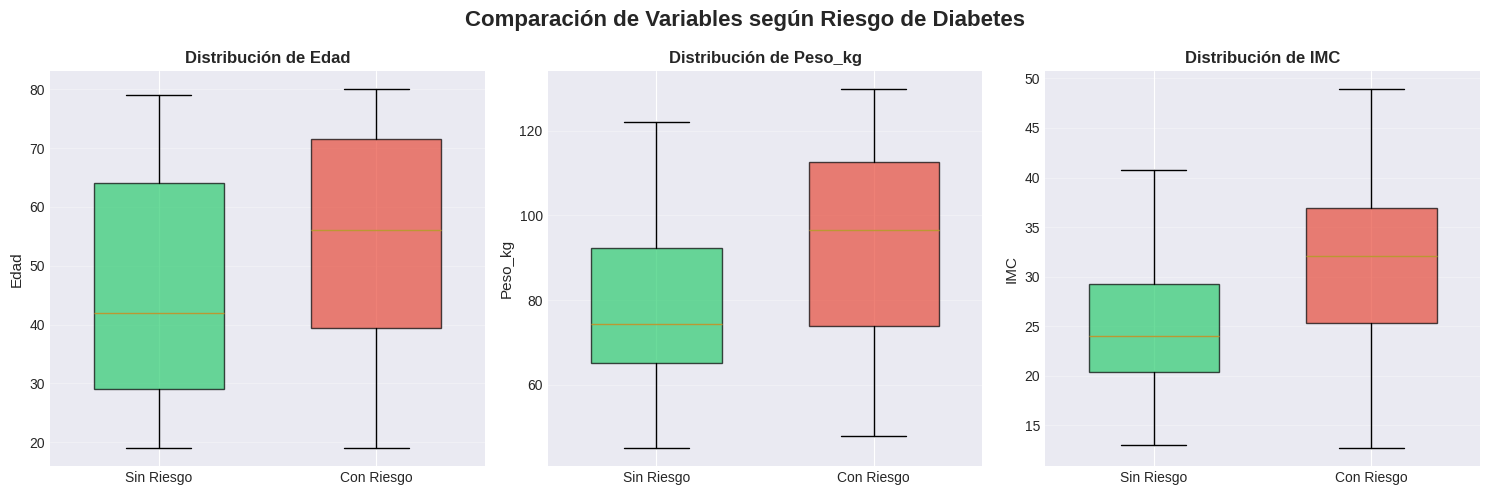

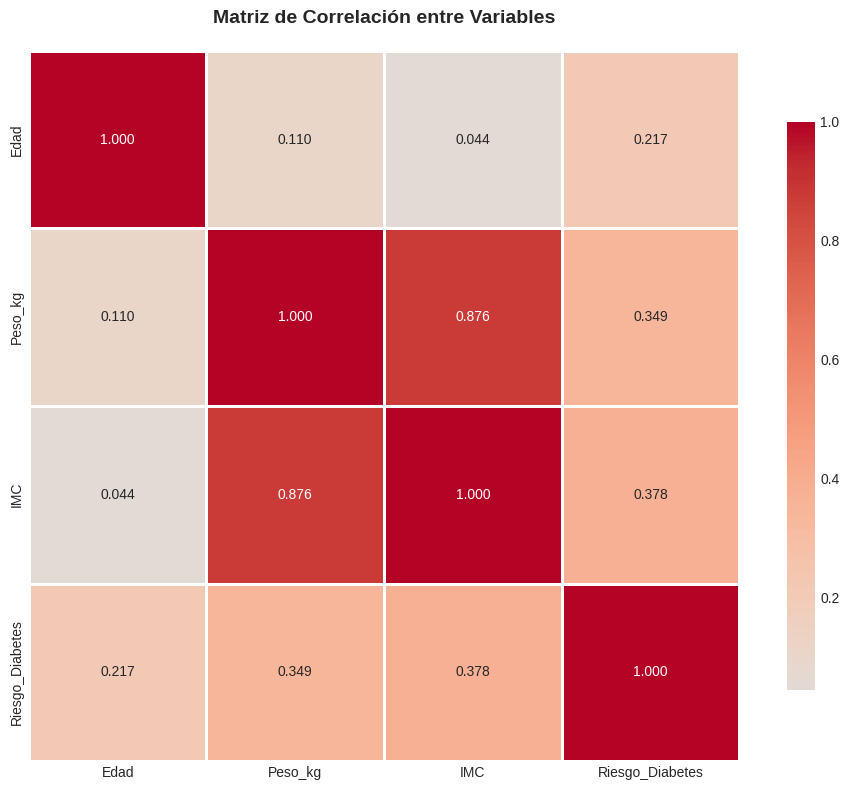

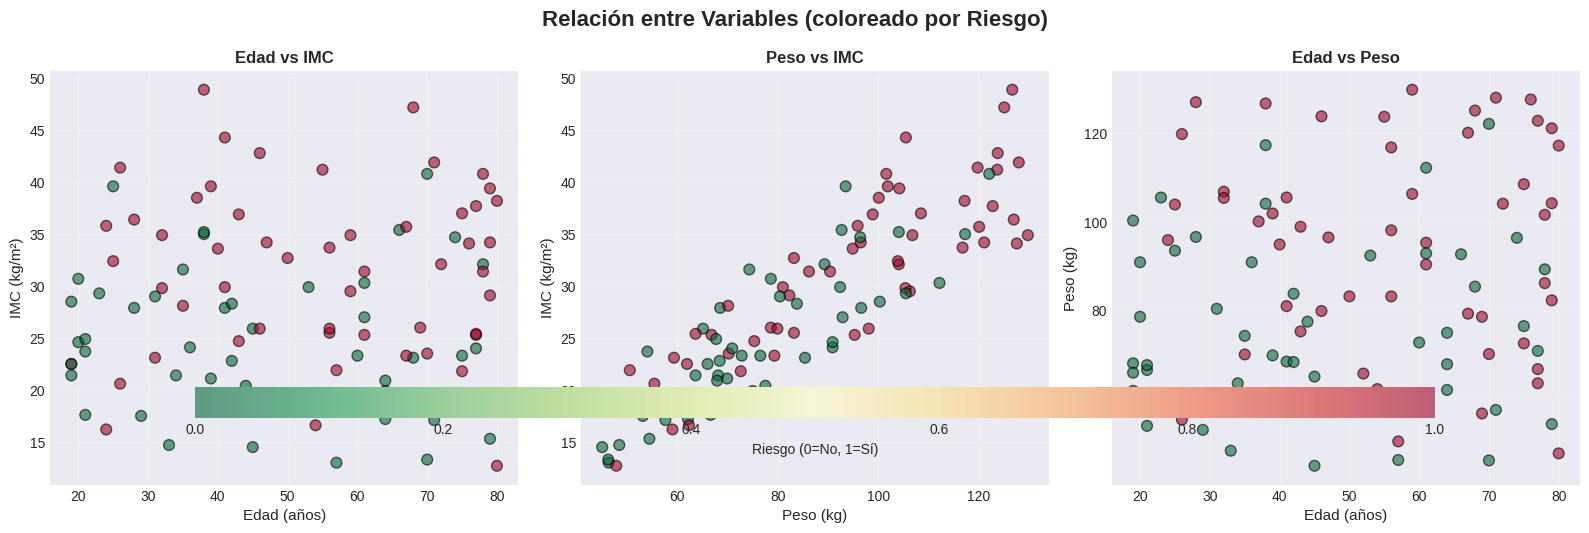

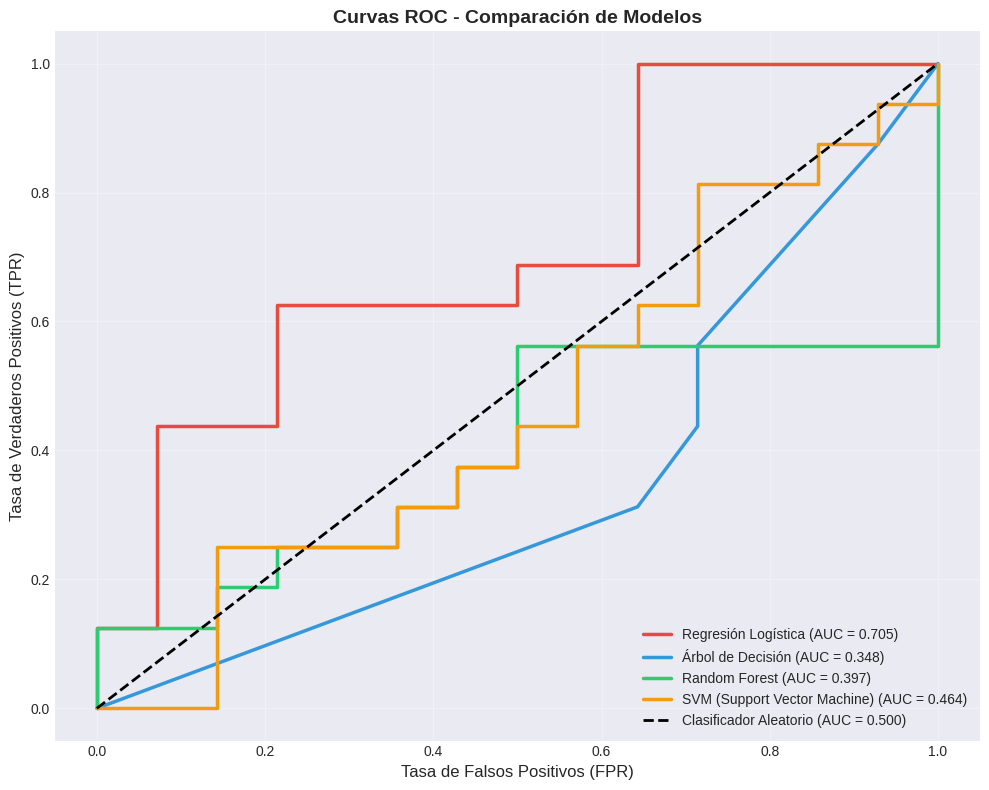

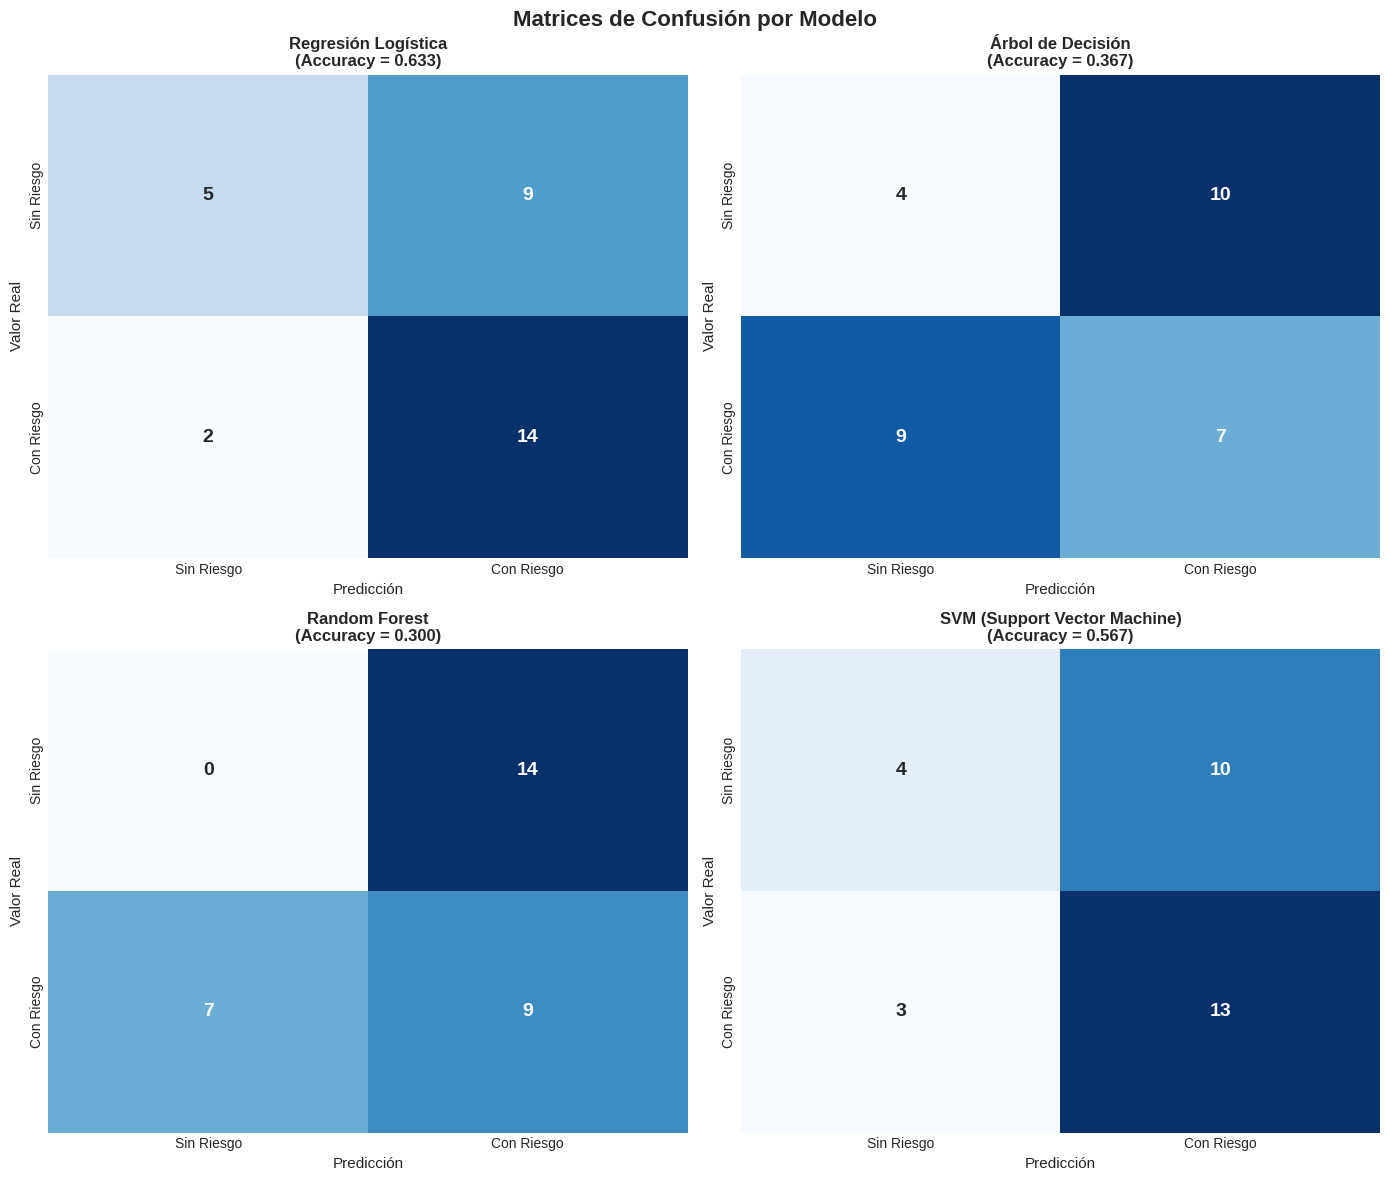

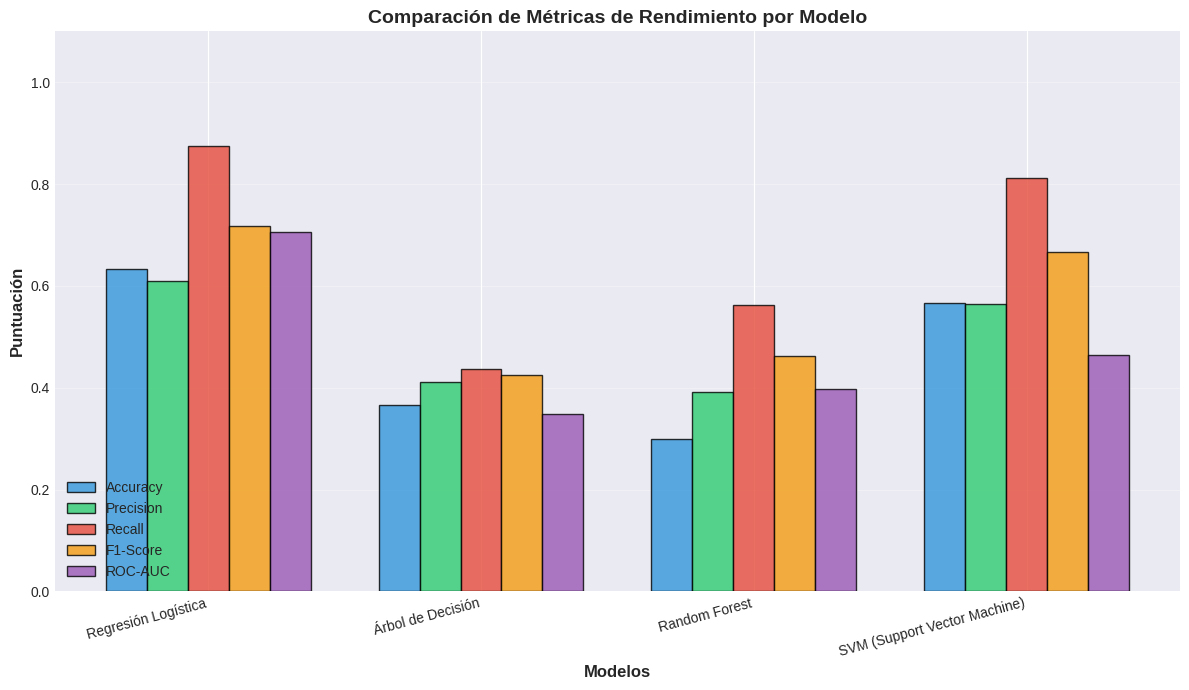

In [1]:
# ============================================================================
# PROYECTO: PREDICCIÓN DE RIESGO DE DIABETES
# Análisis completo con 4 modelos de Machine Learning
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_curve, auc, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

# Modelos a utilizar
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("PROYECTO: PREDICCIÓN DE RIESGO DE DIABETES")
print("="*70)

# ============================================================================
# 1. GENERACIÓN DEL DATASET
# ============================================================================
print("\n1. GENERACIÓN DEL DATASET")
print("-"*70)

np.random.seed(42)

def generar_dataset_diabetes(n_registros=100):
    """
    Genera un dataset sintético para predicción de riesgo de diabetes.

    Variables:
    - Edad: 18-80 años
    - Peso: 45-130 kg
    - IMC: Calculado como peso/estatura²
    - Riesgo_Diabetes: Variable objetivo (0=No, 1=Sí)

    La probabilidad de riesgo aumenta con IMC y edad usando función sigmoide.
    """
    edad = np.random.randint(18, 81, size=n_registros)
    peso = np.random.uniform(45, 130, size=n_registros)
    estatura = np.random.uniform(1.50, 1.95, size=n_registros)
    imc = peso / (estatura**2)

    # Probabilidad de riesgo basada en IMC y edad
    probabilidad = 1 / (1 + np.exp(-(0.15 * imc + 0.03 * edad - 6)))
    riesgo = (np.random.random(n_registros) < probabilidad).astype(int)

    df = pd.DataFrame({
        'Edad': edad,
        'Peso_kg': np.round(peso, 1),
        'IMC': np.round(imc, 1),
        'Riesgo_Diabetes': riesgo
    })

    return df

# Generar dataset
dataset = generar_dataset_diabetes(100)

print(f"Dataset generado: {dataset.shape[0]} registros, {dataset.shape[1]} columnas")
print("\nPrimeras 5 filas:")
print(dataset.head())

print("\n\nEstadísticas descriptivas:")
print(dataset.describe())

print("\n\nDistribución de la variable objetivo:")
print(dataset['Riesgo_Diabetes'].value_counts())
print(f"\nProporción de riesgo: {dataset['Riesgo_Diabetes'].mean()*100:.1f}%")

# ============================================================================
# 2. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ============================================================================
print("\n\n2. ANÁLISIS EXPLORATORIO DE DATOS")
print("-"*70)

# Verificar valores nulos
print("Valores nulos por columna:")
print(dataset.isnull().sum())

# Verificar duplicados
print(f"\nRegistros duplicados: {dataset.duplicated().sum()}")

# Matriz de correlación
print("\nMatriz de correlación:")
correlation_matrix = dataset.corr()
print(correlation_matrix)

# ============================================================================
# 3. VISUALIZACIONES DEL DATASET
# ============================================================================
print("\n\n3. GENERANDO VISUALIZACIONES...")
print("-"*70)

# Figura 1: Distribución de variables
fig1, axes = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle('Distribución de Variables del Dataset', fontsize=16, fontweight='bold')

# Edad
axes[0, 0].hist(dataset['Edad'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Edad (años)', fontsize=11)
axes[0, 0].set_ylabel('Frecuencia', fontsize=11)
axes[0, 0].set_title('Distribución de Edad', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Peso
axes[0, 1].hist(dataset['Peso_kg'], bins=20, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Peso (kg)', fontsize=11)
axes[0, 1].set_ylabel('Frecuencia', fontsize=11)
axes[0, 1].set_title('Distribución de Peso', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# IMC
axes[1, 0].hist(dataset['IMC'], bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('IMC (kg/m²)', fontsize=11)
axes[1, 0].set_ylabel('Frecuencia', fontsize=11)
axes[1, 0].set_title('Distribución de IMC', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Riesgo de Diabetes
riesgo_counts = dataset['Riesgo_Diabetes'].value_counts()
axes[1, 1].bar(['Sin Riesgo', 'Con Riesgo'], riesgo_counts.values,
               color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.7)
axes[1, 1].set_ylabel('Frecuencia', fontsize=11)
axes[1, 1].set_title('Distribución de Riesgo de Diabetes', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(riesgo_counts.values):
    axes[1, 1].text(i, v + 1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('distribucion_variables.png', dpi=300, bbox_inches='tight')
print("✓ Guardado: distribucion_variables.png")

# Figura 2: Boxplots por grupo de riesgo
fig2, axes = plt.subplots(1, 3, figsize=(15, 5))
fig2.suptitle('Comparación de Variables según Riesgo de Diabetes',
              fontsize=16, fontweight='bold')

variables = ['Edad', 'Peso_kg', 'IMC']
colores = ['#3498db', '#e67e22', '#9b59b6']

for idx, var in enumerate(variables):
    bp = axes[idx].boxplot([dataset[dataset['Riesgo_Diabetes']==0][var],
                            dataset[dataset['Riesgo_Diabetes']==1][var]],
                           labels=['Sin Riesgo', 'Con Riesgo'],
                           patch_artist=True,
                           widths=0.6)

    for patch, color in zip(bp['boxes'], ['#2ecc71', '#e74c3c']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes[idx].set_ylabel(var, fontsize=11)
    axes[idx].set_title(f'Distribución de {var}', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('boxplots_riesgo.png', dpi=300, bbox_inches='tight')
print("✓ Guardado: boxplots_riesgo.png")

# Figura 3: Matriz de correlación
fig3, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            ax=ax)
ax.set_title('Matriz de Correlación entre Variables', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('matriz_correlacion.png', dpi=300, bbox_inches='tight')
print("✓ Guardado: matriz_correlacion.png")

# Figura 4: Scatter plots con colores por riesgo
fig4, axes = plt.subplots(1, 3, figsize=(16, 5))
fig4.suptitle('Relación entre Variables (coloreado por Riesgo)',
              fontsize=16, fontweight='bold')

# Edad vs IMC
scatter1 = axes[0].scatter(dataset['Edad'], dataset['IMC'],
                          c=dataset['Riesgo_Diabetes'], cmap='RdYlGn_r',
                          alpha=0.6, edgecolors='black', s=60)
axes[0].set_xlabel('Edad (años)', fontsize=11)
axes[0].set_ylabel('IMC (kg/m²)', fontsize=11)
axes[0].set_title('Edad vs IMC', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Peso vs IMC
scatter2 = axes[1].scatter(dataset['Peso_kg'], dataset['IMC'],
                          c=dataset['Riesgo_Diabetes'], cmap='RdYlGn_r',
                          alpha=0.6, edgecolors='black', s=60)
axes[1].set_xlabel('Peso (kg)', fontsize=11)
axes[1].set_ylabel('IMC (kg/m²)', fontsize=11)
axes[1].set_title('Peso vs IMC', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Edad vs Peso
scatter3 = axes[2].scatter(dataset['Edad'], dataset['Peso_kg'],
                          c=dataset['Riesgo_Diabetes'], cmap='RdYlGn_r',
                          alpha=0.6, edgecolors='black', s=60)
axes[2].set_xlabel('Edad (años)', fontsize=11)
axes[2].set_ylabel('Peso (kg)', fontsize=11)
axes[2].set_title('Edad vs Peso', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

# Leyenda compartida
fig4.colorbar(scatter3, ax=axes, label='Riesgo (0=No, 1=Sí)',
             orientation='horizontal', pad=0.1, aspect=40)

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=300, bbox_inches='tight')
print("✓ Guardado: scatter_plots.png")

# ============================================================================
# 4. PREPARACIÓN DE DATOS - DIVISIÓN 70/30
# ============================================================================
print("\n\n4. PREPARACIÓN DE DATOS (División 70/30)")
print("-"*70)

# Separar características (X) y variable objetivo (y)
X = dataset[['Edad', 'Peso_kg', 'IMC']].values
y = dataset['Riesgo_Diabetes'].values

# División 70% entrenamiento, 30% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} registros ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Conjunto de prueba: {X_test.shape[0]} registros ({X_test.shape[0]/len(X)*100:.0f}%)")

print(f"\nDistribución en entrenamiento:")
print(f"  Sin riesgo: {np.sum(y_train==0)} ({np.sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"  Con riesgo: {np.sum(y_train==1)} ({np.sum(y_train==1)/len(y_train)*100:.1f}%)")

print(f"\nDistribución en prueba:")
print(f"  Sin riesgo: {np.sum(y_test==0)} ({np.sum(y_test==0)/len(y_test)*100:.1f}%)")
print(f"  Con riesgo: {np.sum(y_test==1)} ({np.sum(y_test==1)/len(y_test)*100:.1f}%)")

# Normalización de datos (importante para algunos modelos)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Datos normalizados usando StandardScaler")

# ============================================================================
# 5. ENTRENAMIENTO DE LOS 4 MODELOS
# ============================================================================
print("\n\n5. ENTRENAMIENTO DE MODELOS")
print("-"*70)

# Diccionario para almacenar modelos y resultados
modelos = {
    'Regresión Logística': LogisticRegression(random_state=42, max_iter=1000),
    'Árbol de Decisión': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5),
    'SVM (Support Vector Machine)': SVC(kernel='rbf', probability=True, random_state=42)
}

resultados = {}

for nombre, modelo in modelos.items():
    print(f"\nEntrenando: {nombre}...")

    # Entrenar (SVM y Regresión Logística usan datos escalados)
    if nombre in ['SVM (Support Vector Machine)', 'Regresión Logística']:
        modelo.fit(X_train_scaled, y_train)
        y_pred = modelo.predict(X_test_scaled)
        y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
    else:
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        y_proba = modelo.predict_proba(X_test)[:, 1]

    # Calcular métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Guardar resultados
    resultados[nombre] = {
        'modelo': modelo,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr,
        'confusion_matrix': cm
    }

    print(f"  ✓ Accuracy: {acc:.4f}")
    print(f"  ✓ ROC-AUC: {roc_auc:.4f}")

# ============================================================================
# 6. TABLA COMPARATIVA DE RESULTADOS
# ============================================================================
print("\n\n6. COMPARACIÓN DE MODELOS")
print("-"*70)

# Crear tabla comparativa
tabla_resultados = pd.DataFrame({
    'Modelo': list(resultados.keys()),
    'Accuracy': [r['accuracy'] for r in resultados.values()],
    'Precision': [r['precision'] for r in resultados.values()],
    'Recall': [r['recall'] for r in resultados.values()],
    'F1-Score': [r['f1_score'] for r in resultados.values()],
    'ROC-AUC': [r['roc_auc'] for r in resultados.values()]
})

print("\nMÉTRICAS DE RENDIMIENTO:")
print(tabla_resultados.to_string(index=False))

# Identificar mejor modelo por ROC-AUC
mejor_modelo = tabla_resultados.loc[tabla_resultados['ROC-AUC'].idxmax()]
print(f"\n🏆 MEJOR MODELO (por ROC-AUC): {mejor_modelo['Modelo']}")
print(f"   ROC-AUC = {mejor_modelo['ROC-AUC']:.4f}")

# Guardar tabla
tabla_resultados.to_csv('comparacion_modelos.csv', index=False)
print("\n✓ Tabla guardada: comparacion_modelos.csv")

# ============================================================================
# 7. VISUALIZACIÓN: CURVAS ROC
# ============================================================================
print("\n\n7. GENERANDO CURVAS ROC...")
print("-"*70)

fig5, ax = plt.subplots(figsize=(10, 8))

colores_roc = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for idx, (nombre, res) in enumerate(resultados.items()):
    ax.plot(res['fpr'], res['tpr'],
            label=f"{nombre} (AUC = {res['roc_auc']:.3f})",
            linewidth=2.5, color=colores_roc[idx])

# Línea diagonal (clasificador aleatorio)
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Clasificador Aleatorio (AUC = 0.500)')

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC - Comparación de Modelos', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])

plt.tight_layout()
plt.savefig('curvas_roc.png', dpi=300, bbox_inches='tight')
print("✓ Guardado: curvas_roc.png")

# ============================================================================
# 8. VISUALIZACIÓN: MATRICES DE CONFUSIÓN
# ============================================================================
print("\n\n8. GENERANDO MATRICES DE CONFUSIÓN...")
print("-"*70)

fig6, axes = plt.subplots(2, 2, figsize=(14, 12))
fig6.suptitle('Matrices de Confusión por Modelo', fontsize=16, fontweight='bold')

axes = axes.ravel()

for idx, (nombre, res) in enumerate(resultados.items()):
    cm = res['confusion_matrix']

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Sin Riesgo', 'Con Riesgo'],
                yticklabels=['Sin Riesgo', 'Con Riesgo'],
                cbar=False, ax=axes[idx], annot_kws={'size': 14, 'weight': 'bold'})

    axes[idx].set_xlabel('Predicción', fontsize=11)
    axes[idx].set_ylabel('Valor Real', fontsize=11)
    axes[idx].set_title(f'{nombre}\n(Accuracy = {res["accuracy"]:.3f})',
                       fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=300, bbox_inches='tight')
print("✓ Guardado: matrices_confusion.png")

# ============================================================================
# 9. COMPARACIÓN VISUAL DE MÉTRICAS
# ============================================================================
print("\n\n9. GENERANDO GRÁFICO COMPARATIVO DE MÉTRICAS...")
print("-"*70)

fig7, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(resultados))
width = 0.15

metricas_nombres = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colores_metricas = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for i, metrica in enumerate(metricas_nombres):
    valores = tabla_resultados[metrica].values
    ax.bar(x + i*width, valores, width, label=metrica,
           color=colores_metricas[i], alpha=0.8, edgecolor='black')

ax.set_xlabel('Modelos', fontsize=12, fontweight='bold')
ax.set_ylabel('Puntuación', fontsize=12, fontweight='bold')
ax.set_title('Comparación de Métricas de Rendimiento por Modelo',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(tabla_resultados['Modelo'], rotation=15, ha='right')
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.savefig('comparacion_metricas.png', dpi=300, bbox_inches='tight')
print("✓ Guardado: comparacion_metricas.png")

# ============================================================================
# 10. REPORTE DETALLADO POR MODELO
# ============================================================================
print("\n\n10. REPORTES DETALLADOS DE CLASIFICACIÓN")
print("="*70)

for nombre, res in resultados.items():
    print(f"\n{'='*70}")
    print(f"MODELO: {nombre}")
    print(f"{'='*70}")
    print(classification_report(y_test, res['y_pred'],
                                target_names=['Sin Riesgo', 'Con Riesgo']))

# ============================================================================
# RESUMEN FINAL
# ============================================================================
print("\n\n" + "="*70)
print("PROYECTO COMPLETADO EXITOSAMENTE")
print("="*70)
print("\nArchivos generados:")
print("  1. dataset_diabetes.csv - Dataset original")
print("  2. comparacion_modelos.csv - Tabla de métricas")
print("  3. distribucion_variables.png - Histogramas")
print("  4. boxplots_riesgo.png - Comparación por grupos")
print("  5. matriz_correlacion.png - Mapa de calor")
print("  6. scatter_plots.png - Relaciones entre variables")
print("  7. curvas_roc.png - Curvas ROC de todos los modelos")
print("  8. matrices_confusion.png - Matrices de confusión")
print("  9. comparacion_metricas.png - Gráfico comparativo")

print(f"\n🏆 Modelo recomendado: {mejor_modelo['Modelo']}")
print(f"   Con ROC-AUC de {mejor_modelo['ROC-AUC']:.4f}")
print("\n" + "="*70)